# Visium HD Spatial Transcriptomics Quickstart

A condensed walkthrough of Visium HD analysis, run on the **10x Genomics Human CRC Patient 1** dataset.

**The paper.** Oliveira et al., "High-definition spatial transcriptomic profiling of immune cell populations in colorectal cancer", *Nature Genetics* 57, 1512-1523 (2025) ([link](https://www.nature.com/articles/s41588-025-02193-3)). The study profiled five FFPE human colorectal cancer samples with Visium HD and mapped macrophage and T cell populations to spatial niches with pro-tumor and anti-tumor roles. We use the Patient 1 sample.

**The dataset.** Visium HD captures the whole transcriptome on a continuous grid of 2 um squares. Space Ranger aggregates those squares into bins: 2 um (max resolution, very sparse, rarely used directly), 8 um (about 1 to 3 cells per bin), and 16 um (about 5 to 15 cells per bin). We start at 8 um because it balances resolution against signal density and, unlike finer bins, does not require nuclei segmentation of the H&E image. This notebook works with a random subsample of about 40K 8 um bins plus the published author cell type labels.

---

## From tissue to matrix: Space Ranger

Before any of this notebook runs, the raw data has to come out of **Space Ranger**, the 10x pipeline that turns sequencing reads and the H&E image into a spatial gene-by-bin count matrix.

**What goes in:**

- FASTQ files: the raw Illumina reads, carrying the spatial barcode, UMI, and gene sequence for every captured molecule.
- Reference transcriptome: the prebuilt 10x reference for the species (human GRCh38 here).
- Probe set CSV: the Visium HD probe list, matched to the assay chemistry.
- Slide serial number and capture area ID: printed on the slide, used to look up the fiducial layout.
- CytAssist and microscope H&E images: aligned so barcodes land on the right tissue coordinates.

**What comes out (the parts we use):**

- `filtered_feature_bc_matrix.h5`: the gene-by-bin counts in one HDF5 file. This is what we read into AnnData.
- `spatial/tissue_positions.parquet`: each bin's pixel coordinates on the H&E. This is what makes the data spatial.
- `spatial/scalefactors_json.json`: pixel-to-um conversion, needed to overlay bins on the image.
- `spatial/tissue_hires_image.png` and `tissue_lowres_image.png`: the H&E to plot under the bins.

Space Ranger also writes `segmented_outputs/` (one row per cell, from nuclei segmentation), `cloupe` files for the Loupe Browser, and `web_summary.html` for QC. We don't use those here, but they sit in the same output folder, shown below.

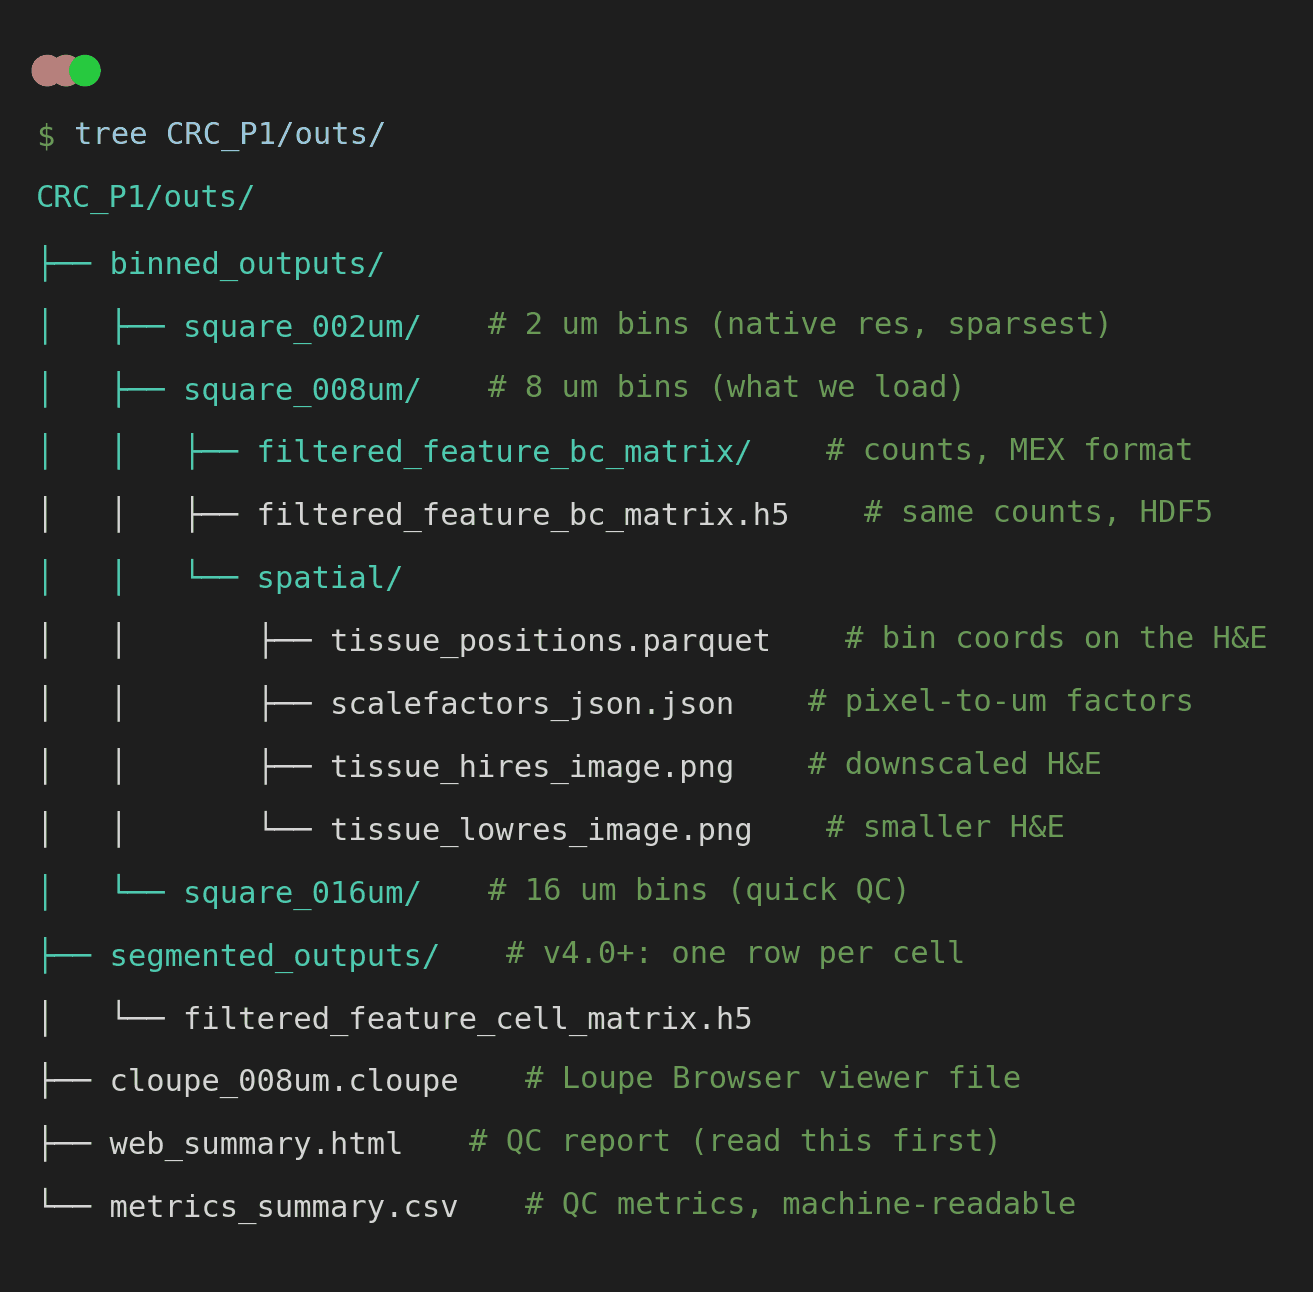

*The Space Ranger output folder. We pull four files from `square_008um/` and its `spatial/` subfolder.*

### Which resolution we use

Space Ranger writes the same tissue at three bin sizes. We load `binned_outputs/square_008um/filtered_feature_bc_matrix.h5`.

8 um sits at roughly 1 to 3 cells per bin, which keeps enough counts per bin to cluster and annotate without needing nuclei segmentation of the H&E. The 2 um bins are at native resolution but too sparse to use directly, and the 16 um bins blur too many cell types together for annotation. When you need true single-cell resolution, the route is `segmented_outputs/`, not a finer bin.

## Setup

Install the required packages and pull the pre-processed data from Figshare. The download includes a binned count matrix, a pre-computed annotated object, ground-truth labels, and an H&E tissue image.

In [ ]:
# Package installation + data download
import os, sys, subprocess
from pathlib import Path

# Install packages
print("Installing packages...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "scanpy>=1.10", "squidpy>=1.6", "anndata>=0.10",
    "numpy>=1.24", "pandas>=2.0", "scipy>=1.11",
    "matplotlib>=3.7", "seaborn>=0.13",
    "scikit-image>=0.21", "Pillow>=10",
    "igraph", "leidenalg",
    "tqdm>=4.65", "requests>=2.31", "h5py>=3.9", "pyarrow>=13",
])
print("Done.")

# Download precomputed data from Figshare. The main h5ads + spatial images
# live in one article; the LIANA results parquet is published separately.
FIGSHARE_ARTICLE_IDS = ["31937262", "32273760"]

DATA_DIR = Path("/content/data")
PRECOMPUTED_DIR = DATA_DIR / "precomputed"
SPATIAL_DIR = PRECOMPUTED_DIR / "spatial"
PRECOMPUTED_DIR.mkdir(parents=True, exist_ok=True)
SPATIAL_DIR.mkdir(parents=True, exist_ok=True)

RAW_H5AD = PRECOMPUTED_DIR / "crc_p1_raw_50k.h5ad"
ANNOT_H5AD = PRECOMPUTED_DIR / "crc_p1_annotated_50k.h5ad"
LIANA_PARQUET = PRECOMPUTED_DIR / "crc_p1_liana_full.parquet"

SPATIAL_FILENAMES = {
    "tissue_hires_image.png",
    "tissue_lowres_image.png",
    "scalefactors_json.json",
}

def _target_path(name):
    return SPATIAL_DIR / name if name in SPATIAL_FILENAMES else PRECOMPUTED_DIR / name

def download_file(url, dest, desc="Downloading"):
    import requests
    from tqdm.auto import tqdm
    tmp = dest.with_suffix(dest.suffix + ".part")
    with requests.get(url, stream=True, timeout=(60, None)) as resp:
        resp.raise_for_status()
        total = int(resp.headers.get("content-length", 0))
        with open(tmp, "wb") as f, tqdm(total=total, unit="B", unit_scale=True, desc=desc) as pbar:
            for chunk in resp.iter_content(chunk_size=8 * 1024 * 1024):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))
    tmp.replace(dest)
    print(f"Saved: {dest.relative_to(DATA_DIR)} ({dest.stat().st_size / 1e6:.2f} MB)")

def fetch_figshare_files():
    import requests
    entries = []
    for aid in FIGSHARE_ARTICLE_IDS:
        resp = requests.get(f"https://api.figshare.com/v2/articles/{aid}/files", timeout=60)
        resp.raise_for_status()
        entries.extend(resp.json())
    return entries

needed = [
    RAW_H5AD,
    ANNOT_H5AD,
    LIANA_PARQUET,
    SPATIAL_DIR / "tissue_hires_image.png",
    SPATIAL_DIR / "tissue_lowres_image.png",
    SPATIAL_DIR / "scalefactors_json.json",
]

if not all(p.exists() for p in needed):
    print("Downloading precomputed data from Figshare (per file)...")
    for entry in fetch_figshare_files():
        name = entry["name"]
        dest = _target_path(name)
        expected_size = entry.get("size")
        if dest.exists() and expected_size is not None and dest.stat().st_size == expected_size:
            print(f"Skipping (already present): {dest.relative_to(DATA_DIR)}")
            continue
        download_file(entry["download_url"], dest, desc=name)
    print("Download complete.")
else:
    print("Precomputed data already downloaded.")

# Clone repo for utils.py
REPO_URL = "https://github.com/stevenpastor/spatial_transcriptomics_resources.git"
REPO_DIR = Path("/content/spatial_tutorial")
if not REPO_DIR.exists():
    print("Cloning tutorial repo (for utility functions)...")
    subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)])
SCRIPTS_DIR = REPO_DIR / "scripts"
print("Ready.")

In [ ]:
import sys, os, time, warnings, gc
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import squidpy as sq
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, fontsize=12)

# Paths
DATA_DIR = Path("/content/data")
PRECOMPUTED_DIR = DATA_DIR / "precomputed"
FIG_DIR = Path("/content/figures")
FIG_DIR.mkdir(exist_ok=True)

sys.path.insert(0, str(SCRIPTS_DIR))
from utils import (
    load_visium_hd_binned,
    compute_qc_metrics,
    spatial_outlier_detection,
)

print(f"scanpy {sc.__version__}, squidpy {sq.__version__}")

## Data Loading

We load a random subsample of the full ~500K+ 8 um binned CRC Patient 1 dataset, created by `scripts/generate_precomputed.py` to keep files under 100 MB for Colab. Filenames say "50k" (the target), but the actual bin count drifts a little because of filtering.

In [ ]:
%%time
# List precomputed files
for f in sorted(PRECOMPUTED_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6 if f.is_file() else 0
    print(f"  {f.name:40s}  {size_mb:6.1f} MB" if f.is_file() else f"  {f.name}/")

# Load 8 um binned data (random subsample from the full dataset)
adata_8um = sc.read_h5ad(PRECOMPUTED_DIR / "crc_p1_raw_50k.h5ad")
print(f"\nLoaded: {adata_8um.shape[0]:,} bins x {adata_8um.shape[1]:,} genes")
print(f"Spatial range X: [{adata_8um.obsm['spatial'][:,0].min():.0f}, {adata_8um.obsm['spatial'][:,0].max():.0f}]")
print(f"Spatial range Y: [{adata_8um.obsm['spatial'][:,1].min():.0f}, {adata_8um.obsm['spatial'][:,1].max():.0f}]")
if sparse.issparse(adata_8um.X):
    print(f"Median UMIs/bin: {np.median(adata_8um.X.sum(axis=1).A1):.0f}")
    print(f"Median genes/bin: {np.median((adata_8um.X > 0).sum(axis=1).A1):.0f}")

# Ground-truth annotations (from the original study group, not us)
if "UnsupervisedL1" in adata_8um.obs.columns:
    print(f"\nGround-truth annotations present: {adata_8um.obs['UnsupervisedL1'].notna().sum():,} / {adata_8um.shape[0]:,} bins")
    print(adata_8um.obs["UnsupervisedL1"].value_counts().to_string())

## What's inside the AnnData object

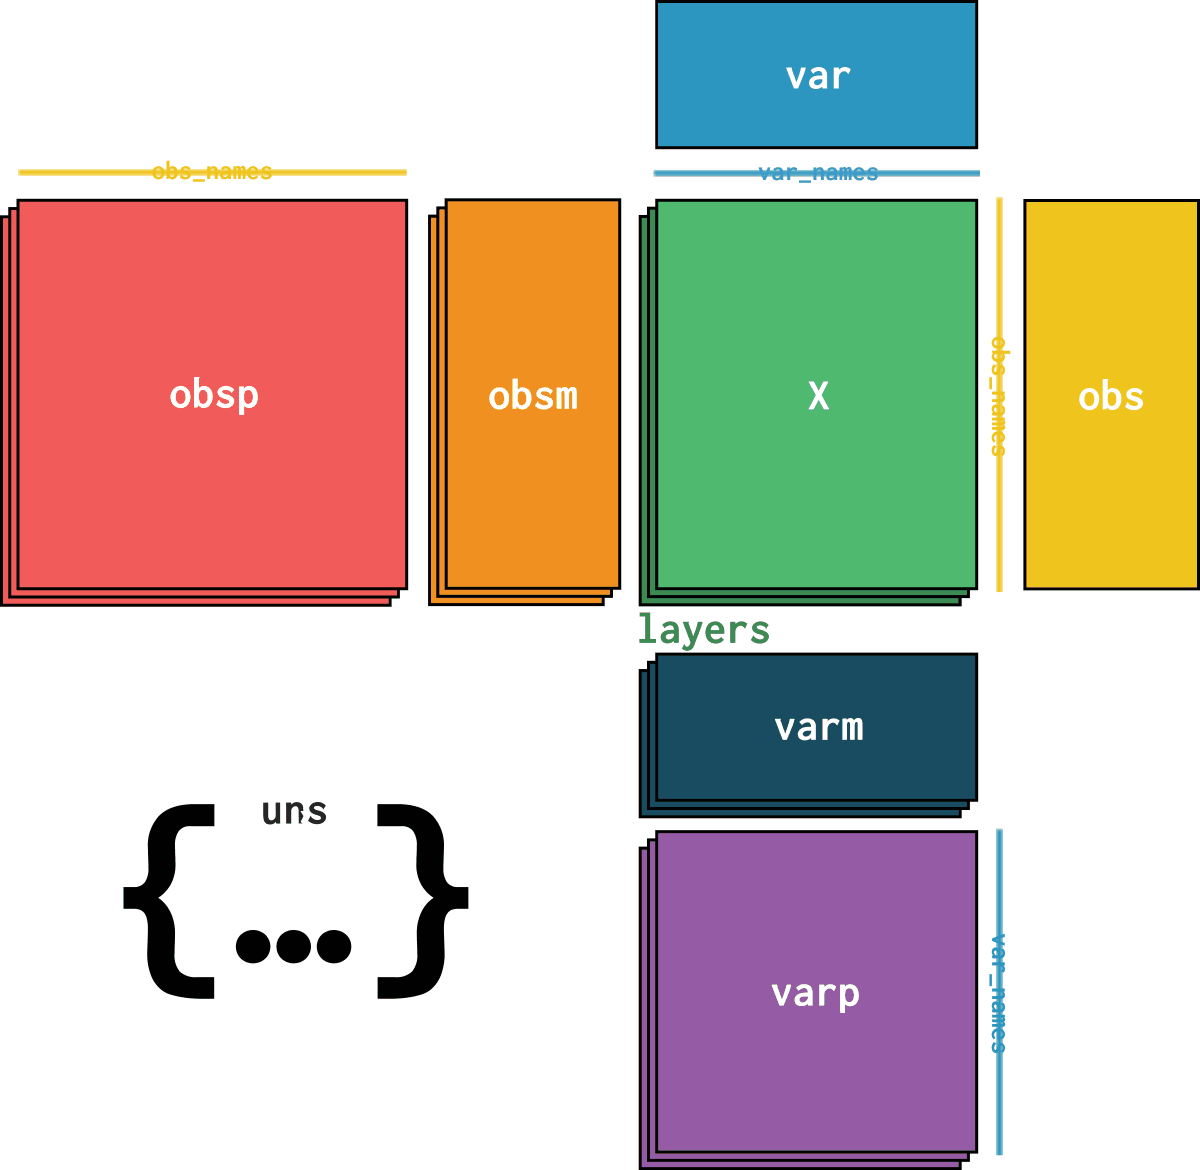

*AnnData data structure. Source: anndata documentation (scverse), https://anndata.readthedocs.io*

Everything we just loaded lives in one AnnData object, `adata_8um`. The pieces:

- **`X`**: the counts. A sparse matrix, bins as rows, genes as columns.
- **`obs`**: the per-bin table, one row per bin, barcodes as the index. The ground-truth `UnsupervisedL1` labels are a column here.
- **`var`**: the per-gene table, one row per gene.
- **`obsm`**: per-bin matrices, keyed by name. This is the difference from `obs`: `obs` holds one value per bin per column, `obsm` holds a whole array per bin. The spatial coordinates are `obsm['spatial']`, and the UMAP computed later in this notebook lands here as `obsm['X_umap']`.
- **`uns`**: unstructured extras. The H&E image is `uns['spatial_image']` and the pixel-to-um factors are `uns['scalefactors']`.
- **`layers`** and **`raw`**: alternate copies of the matrix, for example counts kept before normalization.

`obs` and `var` describe the two axes, `obsm` and `varm` attach matrices to them, and `uns` is the catch-all. The figure shows the general layout; not every slot is filled in this dataset.

## Spatial QC

We still run the standard scRNA-seq QC on every bin (UMIs per bin, genes per bin, mitochondrial %, complexity) and apply global cutoffs at the filtering step. That part is the same as scRNA-seq QC, so we skip the walkthrough here and leave it for you to read up on. This section covers the checks that are specific to spatial data. The spatial-specific check computes each bin's z-score for UMIs, genes, and mitochondrial % against its 20 nearest spatial neighbors and removes any bin with |z| > 3 on at least one metric at the filtering step.

### Bins outside tissue

The Visium HD capture area is a 6.5 x 6.5 mm square, but the tissue section rarely fills it. Space Ranger flags each bin as `in_tissue` (1) or off-tissue (0) based on whether it sits under the section. Off-tissue bins only capture ambient RNA, so they have to come out before analysis. Our loading function (`load_visium_hd_binned` in `utils.py`) already restricts to `in_tissue == 1`, but some edge bins under tissue still produce very low signal because they only partly overlap the section.

### Local context vs. global thresholds

A global threshold treats every bin identically: 50 UMIs is suspicious in dense tumor but normal in sparse stroma. Spatial QC compares each bin to its neighbors and flags the ones that drift from their local context, catching tissue folds, air bubbles, and edge artifacts that look fine in a histogram but cluster in space.

In [ ]:
%%time
# Standard scRNA-seq QC metrics (UMIs, genes, mito %, complexity) per bin.
adata_8um = compute_qc_metrics(adata_8um)

# --- Spatial outlier detection ---
print("Computing spatial neighbors (k=20)...")
sq.gr.spatial_neighbors(adata_8um, n_neighs=20, coord_type="generic")

outlier_metrics = ["total_counts", "pct_counts_mt", "n_genes_by_counts"]
total_outliers = np.zeros(adata_8um.shape[0], dtype=bool)
for metric in outlier_metrics:
    outliers = spatial_outlier_detection(adata_8um, metric=metric, z_threshold=3.0)
    n_out = outliers.sum()
    print(f"  {metric:25s}: {n_out:,} outliers ({100*n_out/len(outliers):.2f}%)")
    total_outliers = total_outliers | outliers.values

adata_8um.obs["spatial_outlier"] = total_outliers
print(f"\nTotal spatial outliers: {total_outliers.sum():,} ({100*total_outliers.mean():.2f}%)")

# H&E image and scale factor for the overlay
import json as _json

if "spatial_image" in adata_8um.uns:
    he_image = adata_8um.uns["spatial_image"]
    scalefactors = adata_8um.uns.get("scalefactors", {})
    sf = scalefactors.get("tissue_lowres_scalef", scalefactors.get("tissue_hires_scalef", 1.0))
else:
    from skimage import io as skio
    spatial_dir = PRECOMPUTED_DIR / "spatial"
    he_image = None
    for name in ["tissue_hires_image.png", "tissue_lowres_image.png"]:
        candidate = spatial_dir / name
        if candidate.exists():
            he_image = skio.imread(str(candidate))
            with open(spatial_dir / "scalefactors_json.json") as f:
                scalefactors = _json.load(f)
            key = "tissue_hires_scalef" if "hires" in name else "tissue_lowres_scalef"
            sf = scalefactors.get(key, 1.0)
            break

coords = adata_8um.obsm["spatial"]
fig, (ax_he, ax_out) = plt.subplots(1, 2, figsize=(16, 7))

# Left: all bins overlaid on the H&E
if he_image is not None:
    ax_he.imshow(he_image, alpha=0.3)
    ax_he.scatter(coords[:, 0] * sf, coords[:, 1] * sf,
                  s=0.3, c="red", alpha=0.5, rasterized=True)
    ax_he.set_xlim(0, he_image.shape[1]); ax_he.set_ylim(he_image.shape[0], 0)
else:
    ax_he.scatter(coords[:, 0], coords[:, 1], s=0.3, c="red", alpha=0.5, rasterized=True)
    ax_he.set_aspect("equal"); ax_he.invert_yaxis()
ax_he.axis("off")
ax_he.set_title("Bins on H&E")

# Right: spatial outliers
ax_out.scatter(coords[~total_outliers, 0], coords[~total_outliers, 1],
               s=0.1, c="lightgray", alpha=0.3, rasterized=True, label="Normal")
ax_out.scatter(coords[total_outliers, 0], coords[total_outliers, 1],
               s=1, c="red", alpha=0.6, rasterized=True, label="Outlier")
ax_out.set_aspect("equal"); ax_out.invert_yaxis(); ax_out.axis("off")
ax_out.legend(markerscale=10, fontsize=10)
ax_out.set_title(f"Spatial outliers (n={total_outliers.sum():,})")

plt.tight_layout()
plt.savefig(FIG_DIR / "crc_spatial_outliers.png", dpi=150, bbox_inches="tight")
plt.show()


### What this means

* **Bins on H&E**: every bin drawn as a red dot over the histology. The dots should trace the tissue outline cleanly, confirming bin coordinates register to the H&E before any filtering.

* **Spatial outlier detection**: For every bin we compute a z-score of three QC metrics (`total_counts`, `pct_counts_mt`, `n_genes_by_counts`) against its 20 nearest spatial neighbors and flag any bin where `|z| > 3` on at least one metric. About 3-4% of bins are flagged, with no large contiguous artifact region (tissue fold, air bubble). These bins are removed in QC.

* **Global QC cutoffs**: On top of the spatial checks, bins are filtered on standard cutoffs at the filtering step: minimum and maximum UMIs, minimum genes, and maximum mitochondrial %. We set these from the data (1st and 99.5th percentile of UMIs, 1st percentile of genes, 95th percentile of mito), the same way you would read thresholds off the QC histograms in routine scRNA-seq.

## Filtering and Normalization

The QC filter applied below combines five criteria into a single `keep` mask:

- `total_counts >= min_counts` (1st percentile of `total_counts`, or 10, whichever is larger)
- `total_counts <= max_counts` (99.5th percentile)
- `n_genes_by_counts >= min_genes` (1st percentile, or 5)
- `pct_counts_mt <= max_mt` (95th percentile, capped at 25)
- `~spatial_outlier` (the union of the three spatial-outlier flags from the previous step)

After filtering, we load a precomputed object that has already been normalized, dimensionally reduced, and clustered. The commented-out code below is what those steps look like if you wanted to run them yourself. The panel below shows the QC metrics and Leiden clusters on the UMAP, plus the Leiden clusters mapped back onto the H&E image.

In [ ]:
%%time
# Apply global + spatial QC filters
n_before = adata_8um.shape[0]

min_counts = max(adata_8um.obs["total_counts"].quantile(0.01), 10)
max_counts = adata_8um.obs["total_counts"].quantile(0.995)
min_genes = max(adata_8um.obs["n_genes_by_counts"].quantile(0.01), 5)
max_mt = min(adata_8um.obs["pct_counts_mt"].quantile(0.95), 25)

keep = (
    (adata_8um.obs["total_counts"] >= min_counts) &
    (adata_8um.obs["total_counts"] <= max_counts) &
    (adata_8um.obs["n_genes_by_counts"] >= min_genes) &
    (adata_8um.obs["pct_counts_mt"] <= max_mt) &
    (~adata_8um.obs["spatial_outlier"].astype(bool))
)
adata_8um = adata_8um[keep].copy()
min_cells = max(int(0.001 * adata_8um.shape[0]), 3)
sc.pp.filter_genes(adata_8um, min_cells=min_cells)

print(f"Filtering: {n_before:,} -> {adata_8um.shape[0]:,} bins "
      f"(removed {n_before - adata_8um.shape[0]:,}, "
      f"{100*(n_before - adata_8um.shape[0])/n_before:.1f}%)")

# Load precomputed normalized + clustered data.
# I ran normalization, PCA, UMAP, and Leiden clustering separately and saved
# the result. The bin count differs slightly from the filtering above because
# the precomputed file was generated from a separate run. Here is what those
# steps would look like:
#
# sc.pp.normalize_total(adata_8um, target_sum=1e4)
# sc.pp.log1p(adata_8um)
# sc.pp.highly_variable_genes(adata_8um, n_top_genes=2000, flavor="seurat_v3")
# adata_8um = adata_8um[:, adata_8um.var["highly_variable"]].copy()
# sc.pp.scale(adata_8um, max_value=10)
# sc.tl.pca(adata_8um, n_comps=50)
# sc.pp.neighbors(adata_8um, n_neighbors=15, n_pcs=30)
# sc.tl.umap(adata_8um)
# sc.tl.leiden(adata_8um, resolution=0.5)

adata_8um = sc.read_h5ad(PRECOMPUTED_DIR / "crc_p1_annotated_50k.h5ad")
print(f"Loaded precomputed annotated data: {adata_8um.shape}")
print(f"Leiden clusters: {adata_8um.obs['leiden'].nunique()}")

# QC metrics + Leiden on the UMAP, plus Leiden on the H&E image
fig, axes = plt.subplots(1, 5, figsize=(27, 5))
for ax, metric, cmap in zip(axes[:3],
    ["total_counts", "n_genes_by_counts", "pct_counts_mt"],
    ["viridis", "viridis", "RdYlBu_r"]):
    sc_p = ax.scatter(adata_8um.obsm["X_umap"][:, 0], adata_8um.obsm["X_umap"][:, 1],
                      c=adata_8um.obs[metric], s=0.3, cmap=cmap,
                      edgecolors="none", rasterized=True)
    ax.set_title(metric); plt.colorbar(sc_p, ax=ax, shrink=0.7)

leiden_clusters = sorted(adata_8um.obs["leiden"].unique(), key=int)
leiden_colors = dict(zip(leiden_clusters, plt.cm.tab20(np.linspace(0, 1, len(leiden_clusters)))))

for cl in leiden_clusters:
    mask = (adata_8um.obs["leiden"] == cl).values
    axes[3].scatter(adata_8um.obsm["X_umap"][mask, 0], adata_8um.obsm["X_umap"][mask, 1],
                    s=0.3, label=cl, alpha=0.5, rasterized=True, color=leiden_colors[cl])
axes[3].set_title("Leiden clusters")
axes[3].legend(markerscale=5, fontsize=7, ncol=2, loc="best")

coords = adata_8um.obsm["spatial"]
if he_image is not None:
    axes[4].imshow(he_image, alpha=0.4)
    for cl in leiden_clusters:
        mask = (adata_8um.obs["leiden"] == cl).values
        axes[4].scatter(coords[mask, 0] * sf, coords[mask, 1] * sf,
                        s=0.4, label=cl, alpha=0.6, rasterized=True, color=leiden_colors[cl])
    axes[4].set_xlim(0, he_image.shape[1]); axes[4].set_ylim(he_image.shape[0], 0)
else:
    for cl in leiden_clusters:
        mask = (adata_8um.obs["leiden"] == cl).values
        axes[4].scatter(coords[mask, 0], coords[mask, 1],
                        s=0.4, label=cl, alpha=0.6, rasterized=True, color=leiden_colors[cl])
    axes[4].set_aspect("equal"); axes[4].invert_yaxis()
axes[4].axis("off")
axes[4].set_title("H&E + Leiden clusters")
plt.tight_layout()
plt.savefig(FIG_DIR / "crc_umap_qc_leiden.png", dpi=150, bbox_inches="tight")
plt.show()


### What this means

* Combined spatial + global filtering took out ~22% of bins. After filtering, the UMAP shows clear cluster structure.

* High-count/high-mt bins cluster together in the bottom-right. That is probably biological (metabolically active tumor epithelium) rather than pure artifact, since the same region maps to tumor cell types when we check annotations next.

* On the H&E image the Leiden clusters fall into coherent tissue regions, which confirms the expression clusters track real spatial structure.

## Marker-Based Annotations

Now we annotate bins ourselves using canonical CRC marker gene sets. It is a common approach when ground-truth labels are not available.

**How `sc.tl.score_genes` works:** For each marker panel, scanpy computes a per-bin enrichment score. It takes the mean expression of the marker genes, subtracts the mean expression of a reference set of randomly selected genes with similar expression levels, and returns the difference. That controls for overall expression level, so a bin is not labeled "Tumor" just because it has a lot of total counts. Each bin then gets assigned to whichever panel scored highest. Bins where the top score is too low (<0.05) or too close to the runner-up (margin <0.02) get labeled "Low_confidence."

We use the same broad categories as the published author labels (Oliveira et al., `UnsupervisedL1`) so the two annotation sets line up side by side on the H&E image below.

In [ ]:
%%time
# Marker-based annotation using broad cell types matching the published labels
marker_sets = {
    "Tumor":                  ["EPCAM", "KRT8", "KRT18", "KRT19", "KRT20", "CEACAM5", "MUC1"],
    "Fibroblast":             ["COL1A1", "COL1A2", "COL3A1", "DCN", "LUM", "COL6A1"],
    "Endothelial":            ["PECAM1", "VWF", "EMCN", "KDR", "RAMP2", "PLVAP"],
    "Myeloid":                ["LST1", "TYROBP", "FCER1G", "CTSS", "AIF1", "C1QC", "C1QB"],
    "T cells":                ["CD3D", "CD3E", "TRBC1", "TRBC2", "NKG7", "IL7R", "LTB"],
    "B cells":                ["MS4A1", "CD79A", "CD79B", "MZB1", "JCHAIN", "IGKC", "CD74"],
    "Smooth Muscle":          ["ACTA2", "MYH11", "DES", "TAGLN", "CNN1", "ACTG2"],
    "Intestinal Epithelial":  ["MUC2", "TFF3", "FCGBP", "CLCA1", "ZG16", "AGR2",
                               "FABP1", "FABP2", "ALPI", "VIL1", "SIS"],
}

present_markers = {}
for ct, genes in marker_sets.items():
    present_markers[ct] = [g for g in genes if g in adata_8um.var_names]

score_cols = []
for ct, genes in present_markers.items():
    if len(genes) >= 2:
        score_col = f"{ct}_score"
        sc.tl.score_genes(adata_8um, gene_list=genes, score_name=score_col, use_raw=False)
        score_cols.append(score_col)

score_df = adata_8um.obs[score_cols].copy()
adata_8um.obs["cell_type_marker"] = score_df.idxmax(axis=1).str.replace("_score", "", regex=False)

max_score = score_df.max(axis=1)
sorted_scores = np.sort(score_df.values, axis=1)
second_score = sorted_scores[:, -2] if sorted_scores.shape[1] > 1 else np.zeros(len(score_df))
margin = max_score.values - second_score
adata_8um.obs.loc[(max_score < 0.05) | (margin < 0.02), "cell_type_marker"] = "Low_confidence"

# Shared palette across the published labels and the marker categories
if "UnsupervisedL1" in adata_8um.obs:
    gt_types = sorted(adata_8um.obs["UnsupervisedL1"].dropna().unique())
else:
    gt_types = []
all_cell_types = sorted(set(gt_types) | set(marker_sets) | {"Low_confidence"})
cell_type_palette = dict(zip(all_cell_types, plt.cm.tab20(np.linspace(0, 1, len(all_cell_types)))))

# Side-by-side spatial comparison on the H&E image
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
coords = adata_8um.obsm["spatial"]

if "UnsupervisedL1" in adata_8um.obs:
    gt_mask = adata_8um.obs["UnsupervisedL1"].notna().values
else:
    gt_mask = np.zeros(adata_8um.shape[0], dtype=bool)

panels = [
    (axes[0], adata_8um.obs.get("UnsupervisedL1"), gt_mask, "Ground truth (UnsupervisedL1)"),
    (axes[1], adata_8um.obs["cell_type_marker"], np.ones(adata_8um.shape[0], dtype=bool), "Marker-based annotations"),
]
for ax, labels, base_mask, title in panels:
    if he_image is not None:
        ax.imshow(he_image, alpha=0.4)
    if labels is not None:
        for ct in sorted(labels[base_mask].dropna().unique()):
            m = base_mask & (labels == ct).values
            x = coords[m, 0] * sf if he_image is not None else coords[m, 0]
            y = coords[m, 1] * sf if he_image is not None else coords[m, 1]
            ax.scatter(x, y, s=0.4, label=ct, alpha=0.5, rasterized=True,
                       color=cell_type_palette.get(ct, "lightgray"))
        ax.legend(markerscale=10, fontsize=7, loc="best", framealpha=0.8)
    if he_image is not None:
        ax.set_xlim(0, he_image.shape[1]); ax.set_ylim(he_image.shape[0], 0)
    else:
        ax.set_aspect("equal"); ax.invert_yaxis()
    ax.axis("off"); ax.set_title(title)

plt.tight_layout()
plt.savefig(FIG_DIR / "crc_marker_cell_type_maps.png", dpi=150, bbox_inches="tight")
plt.show()

### What this means

* The spatial patterns hold up well. Tumor fills the lower-right, fibroblast fills the stroma, and intestinal epithelium lines the mucosal surface. The spatial architecture is consistent between our annotations and the ground truth, even in places where the specific labels disagree.

* As in any scRNA-seq workflow, you can sanity-check the assignments by plotting the canonical markers per assigned cell type on a dotplot (`sc.pl.dotplot`). High mean expression and a high fraction of expressing bins along the diagonal tell you the marker panels are catching the right populations. Off-diagonal signal flags non-specific markers (the fibroblast collagen panel here is a known offender).

## Neighborhood Analysis

Which cell types sit next to each other in tissue? **Neighborhood enrichment** answers that by comparing the actual frequency of cell type pairs among spatial neighbors to the frequency you would expect from a random permutation. If Tumor bins are surrounded by other Tumor bins more often than chance, that shows up as self-enrichment. If T cells steer clear of the tumor region, it shows up as negative enrichment.

The algorithm:
1. Build a spatial neighbor graph (k=20 nearest bins)
2. Count how often each pair of cell types appears as neighbors
3. Randomly shuffle the cell type labels many times and recount
4. Compare the real counts to the permuted distribution (z-score)

In [ ]:
%%time
# Neighborhood enrichment
ct_key = "UnsupervisedL1"
adata_nhood = adata_8um[adata_8um.obs[ct_key].notna()].copy()
adata_nhood.obs[ct_key] = adata_nhood.obs[ct_key].astype("category")

sq.gr.spatial_neighbors(adata_nhood, n_neighs=20, coord_type="generic")
sq.gr.nhood_enrichment(adata_nhood, cluster_key=ct_key)

fig, ax = plt.subplots(figsize=(8, 7))
sq.pl.nhood_enrichment(adata_nhood, cluster_key=ct_key, ax=ax)
ax.set_title("Neighborhood Enrichment (ground truth labels)")
plt.tight_layout()
plt.savefig(FIG_DIR / "crc_nhood_enrichment.png", dpi=150, bbox_inches="tight")
plt.show()

del adata_nhood; gc.collect()


### What this means

* **Strong self-enrichment** (bright diagonal) for Tumor, Smooth Muscle, and Intestinal Epithelial. Each of these types forms a contiguous spatial domain.

* **Tumor avoids most other types**: dark entries fill the Tumor row and column off the diagonal. This is consistent with a dense tumor mass and limited immune infiltration. The Tumor-T cell avoidance in particular suggests immune exclusion, which matters for the immunotherapy context.

* **Fibroblast-Intestinal Epithelial**: Negative enrichment, even though both types are abundant. They occupy adjacent but distinct spatial compartments.

## Spatially Variable Genes (SVGs)

Standard differential expression (DE) asks: which genes differ between groups (Tumor vs. Fibroblast, say)? SVG detection asks a different question: which genes have **spatially structured expression patterns**, regardless of any grouping?

**Moran's I** measures spatial autocorrelation. For each gene, it compares expression at each bin to expression at neighboring bins. If nearby bins tend to share expression levels, the gene gets a high I value. If expression is random with respect to location, I stays near zero.

This is useful because:
- It surfaces spatially patterned genes without requiring prior cell type labels
- It can pick up genes with gradients, boundary effects, or regional enrichment that DE would miss
- It validates whether known markers actually are spatially structured in this tissue

In [ ]:
%%time
# SVG detection (subsampled for speed)
n_svg = min(10_000, adata_8um.shape[0])
print(f"Subsampling to {n_svg:,} bins for SVG analysis...")
adata_svg = sc.pp.subsample(adata_8um, n_obs=n_svg, copy=True)
sq.gr.spatial_neighbors(adata_svg, n_neighs=20, coord_type="generic")

if "highly_variable" in adata_svg.var.columns:
    adata_svg_hvg = adata_svg[:, adata_svg.var["highly_variable"]].copy()
else:
    adata_svg_hvg = adata_svg.copy()

print(f"Running Moran's I on {adata_svg_hvg.shape[1]} genes...")
sq.gr.spatial_autocorr(adata_svg_hvg, mode="moran", n_jobs=1)

morans = adata_svg_hvg.uns["moranI"].sort_values("I", ascending=False)
print(f"\nTop 20 SVGs:")
print(morans.head(20)[["I", "pval_norm"]].to_string())

# Plot specific genes from different tissue compartments
# These are the genes we interpret below, so we plot exactly these
plot_genes = ["PIGR", "MUC2", "MUC12", "FCGBP", "DES", "MYH11", "COL1A1", "COL3A1", "CEACAM5"]

# Check which are present in the data
available = [g for g in plot_genes if g in adata_svg.var_names]
missing = [g for g in plot_genes if g not in adata_svg.var_names]
if missing:
    print(f"\nGenes not in data (skipping): {missing}")
print(f"Plotting {len(available)} genes: {available}")

n_genes = len(available)
n_cols = min(5, n_genes)
n_rows = (n_genes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
if n_rows == 1:
    axes = np.atleast_2d(axes)
coords = adata_svg.obsm["spatial"]

for idx, gene in enumerate(available):
    r, c = divmod(idx, n_cols)
    ax = axes[r, c]
    vals = adata_svg[:, gene].X
    expr = vals.toarray().flatten() if sparse.issparse(vals) else np.asarray(vals).flatten()
    i_val = morans.loc[gene, "I"] if gene in morans.index else "N/A"
    i_str = f"{i_val:.3f}" if isinstance(i_val, float) else i_val
    sc_p = ax.scatter(coords[:, 0], coords[:, 1], c=expr, s=1, cmap="magma",
                      edgecolors="none", rasterized=True)
    ax.set_title(f"{gene} (I={i_str})", fontsize=11)
    ax.set_aspect("equal"); ax.invert_yaxis(); ax.axis("off")
    plt.colorbar(sc_p, ax=ax, shrink=0.6)

# Turn off unused axes
for idx in range(n_genes, n_rows * n_cols):
    r, c = divmod(idx, n_cols)
    axes[r, c].axis("off")

plt.suptitle("Spatially Variable Genes", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "crc_svgs.png", dpi=150, bbox_inches="tight")
plt.show()

del adata_svg, adata_svg_hvg; gc.collect()

### What this means

* The plotted genes line up with different tissue compartments. **PIGR/MUC2/MUC12/FCGBP** are mucosal epithelium markers concentrated in the upper-left glandular region. **DES/MYH11** are smooth muscle, localized to the muscularis layer. **COL1A1/COL3A1** are fibroblast/stromal genes. **CEACAM5** is a tumor epithelial marker concentrated in the tumor mass.

* Signal looks sparse (most bins are dark) because dropout is high at 8 um depth. Moran's I still captures the spatial coherence of the non-zero bins, even under heavy dropout.

* All p-values come out as 0 with 10K bins, so what matters for ranking is the I value itself, not statistical significance.

## Cell-Cell Communication

Cells signal to each other through ligand-receptor (L-R) pairs. In spatial data an L-R interaction is only believable if the ligand-expressing and receptor-expressing cell types sit close together in the tissue.

We use **LIANA**, which runs five published L-R methods (CellPhoneDB, CellChat, NATMI, Connectome, SingleCellSignalR) and combines them into one consensus rank. This is the tool the source paper ([Oliveira et al., Nat Genet 2025](https://www.nature.com/articles/s41588-025-02193-3)) used for its Figure 5 analysis.

LIANA is slow on a tissue this size and its output is a small table, so we ran it once offline on the full ~500K-bin P1 tissue and ship the result as `crc_p1_liana_full.parquet`. The cell below loads that file and draws the ECM-signaling dotplot from the paper (Fig 5C): SPP1+ and other macrophages plus CAFs signaling to the tumor subtypes.

In [ ]:
# Load precomputed LIANA results + render the ECM-signaling dotplot
import pyarrow.parquet as pq

if not LIANA_PARQUET.exists():
    raise FileNotFoundError(
        f"Missing {LIANA_PARQUET.name}. Re-run the install cell (it pulls "
        "from Figshare), or rerun scripts/generate_precomputed.py locally."
    )

table = pq.read_table(LIANA_PARQUET)
liana_df = table.to_pandas()
meta = dict(table.schema.metadata or {})
provenance = {
    k.decode().replace("liana_", ""): v.decode(errors="replace")
    for k, v in meta.items()
    if k.decode().startswith("liana_") and k.decode() != "liana_mac_subtype_table_parquet"
}
print(f"LIANA rows: {len(liana_df):,}")
for k in ("groupby", "resource", "n_perms", "n_bins", "subset", "dataset"):
    if k in provenance:
        print(f"  {k+':':10s} {provenance[k]}")


def _liana_dotplot(ax, df, senders, receivers,
                   top_per_pair=3, top_lr=15, title=""):
    """Render one paper-style L-R dotplot for (senders -> receivers) on `ax`."""
    sub = df[df["source"].isin(senders) & df["target"].isin(receivers)].copy()
    if sub.empty:
        ax.set_title(f"{title}\n(no rows for these sources/targets)", fontsize=10)
        ax.axis("off")
        return

    sub["lr"] = sub["ligand_complex"] + " > " + sub["receptor_complex"]
    sub["pair"] = sub["source"].astype(str) + " > " + sub["target"].astype(str)
    tp = (sub.sort_values("magnitude_rank")
            .groupby(["source", "target"], observed=True).head(top_per_pair))
    lr_pairs = tp["lr"].value_counts().head(top_lr).index.tolist()
    sub = sub[sub["lr"].isin(lr_pairs)]

    pair_order = [f"{s} > {t}" for s in senders for t in receivers
                  if f"{s} > {t}" in sub["pair"].unique()]
    lr_score = (sub.assign(s=lambda d: -np.log10(d["magnitude_rank"].clip(lower=1e-4)))
                  .groupby("lr")["s"].sum().sort_values(ascending=False))
    lr_order = lr_score.index.tolist()

    mag = sub.pivot(index="lr", columns="pair",
                    values="magnitude_rank").reindex(index=lr_order, columns=pair_order)
    mean_v = sub.pivot(index="lr", columns="pair",
                       values="lr_means").reindex(index=lr_order, columns=pair_order)

    for i in range(len(lr_order)):
        for j in range(len(pair_order)):
            m, v = mag.iloc[i, j], mean_v.iloc[i, j]
            if pd.isna(m) or pd.isna(v):
                continue
            sig = -np.log10(max(m, 1e-4))
            size = min(20 + v * 60, 280)
            ax.scatter(j, i, s=size, c=sig, cmap="viridis", vmin=0, vmax=3,
                       edgecolors="black", linewidths=0.3, alpha=0.9)

    ax.set_yticks(range(len(lr_order))); ax.set_yticklabels(lr_order, fontsize=8)
    ax.set_xticks(range(len(pair_order)))
    ax.set_xticklabels(pair_order, fontsize=8, rotation=45, ha="right")
    ax.set_xlim(-0.5, len(pair_order) - 0.5)
    ax.set_ylim(-0.5, len(lr_order) - 0.5)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.2, linewidth=0.5)


# -- ECM-signaling dotplot (Oliveira Fig 5C): SPP1+ / other macrophages + CAFs -> tumor --
ecm_senders = ["Macrophage_SPP1+", "Macrophage_other", "CAF", "Fibroblast"]
ecm_receivers = ["Tumor II", "Tumor III", "Tumor V"]

fig, ax = plt.subplots(figsize=(10, 7))
_liana_dotplot(ax, liana_df, ecm_senders, ecm_receivers,
               title="ECM signaling (Oliveira Fig 5C):\nSPP1+ / other macrophages + CAFs -> Tumor II/III/V")

sm = plt.cm.ScalarMappable(norm=plt.Normalize(0, 3), cmap="viridis"); sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02
             ).set_label("-log10(magnitude_rank)", fontsize=9)
fig.suptitle("LIANA top L-R edges  (size = mean expression, color = significance)",
             fontsize=12, y=1.02)
plt.savefig(FIG_DIR / "crc_liana_dotplot.png", dpi=150, bbox_inches="tight")
plt.show()

gc.collect()

### What this means

* **ECM signaling (paper Fig 5C)**: senders are SPP1+ and other macrophages plus CAFs and fibroblasts, receivers are the Tumor II, III, and V subtypes. The strong edges are extracellular matrix and adhesion signals from SPP1+ macrophages and CAFs onto tumor cells.

* **SPP1+ is a pro-tumor program**: SPP1+ macrophages send matrix and adhesion signals to tumor cells, building a niche that promotes invasion and angiogenesis and keeps T cells out. This axis dominates P1, so its macrophage compartment leans toward a pro-tumor balance.

* **The anti-tumor counterpart**: In the source paper's other CRC samples, SELENOP+ macrophages interface with CD4 and CD8 T cells and recruit them into the tumor, an anti-tumor niche. P1 shows little of that, which fits the earlier neighborhood result that T cells are excluded from the P1 tumor mass.

* **For CRC**: the balance between the SPP1+ pro-tumor program and the SELENOP+ anti-tumor, T-cell-recruiting program is what tips colorectal cancer between immune escape and immune attack. P1 sits on the SPP1-dominant, T-cell-excluded side, the side associated with worse outcomes.

* **Scale**: the parquet was computed on the full tissue (`subset: full_tissue` in the provenance print), so these L-R statistics are whole-tissue, not from the subsample used elsewhere.

## Beyond This Tutorial

This notebook covers a core spatial transcriptomics workflow, but a number of other analyses are commonly run on Visium HD data:

### Deconvolution

At 8 um resolution, a single bin may pick up signal from 1 to 3 cells. Deconvolution methods (cell2location, RCTD, stereoscope) estimate the fractional composition of cell types within each bin using a single-cell RNA-seq reference. They become especially valuable at coarser resolutions (16 um, 55 um Visium v1) where bins average over many cells.

### Spatial domains / compartment detection

SpaGCN, STAGATE, BayesSpace, and GraphST identify spatially coherent regions (domains) that share similar expression profiles. Rather than clustering bins in gene-expression space alone, these methods incorporate spatial neighbor graphs to find contiguous tissue compartments such as tumor core, invasive margin, or immune-rich stroma. People sometimes call this "spatial clustering" or "tissue compartment finding."

### Other spatial analyses

- **Spatial trajectory analysis** (stLearn, PAGA with spatial constraints): traces differentiation or disease progression paths through tissue space
- **Niche analysis**: characterize the cellular microenvironment around each cell type and identify distinct tissue niches
- **Gene regulatory network inference**: methods like SCENIC+ adapted for spatial data, to find spatially regulated transcription factor programs
- **Multi-sample integration**: tools like PASTE, SLAT, or STAligner for aligning and comparing spatial data across multiple tissue sections or patients

## Summary

1. **QC**: We dropped ~22% of bins using per-bin thresholds (UMIs, genes, mt%) and spatial outlier detection.
2. **Reference labels**: We use the published author annotations (Oliveira et al., `UnsupervisedL1`) as the cell-type reference for the marker comparison and the neighborhood analysis.
3. **Our annotations**: Marker-based scoring on broad cell types matching the published categories. On the H&E the spatial architecture reproduces the reference, though non-specific fibroblast markers and immune gene dropout at shallow depth blur the per-bin labels.
4. **Spatial analysis**: Neighborhood enrichment confirms tumor self-clustering with immune exclusion. SVGs line up with expected tissue compartment markers.
5. **Cell-cell communication**: LIANA points to SPP1+ macrophages and CAFs as the dominant senders of extracellular matrix and adhesion signals to tumor cells, a pro-tumor lean. The anti-tumor SELENOP+ to T cell niche the source paper describes in its other samples is largely absent in this T-cell-excluded P1 tissue.